In [92]:
# Import required libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf


In [93]:
# Set seaborn theme
sns.set_theme(style="whitegrid", font= 'sans-serif', palette='deep', font_scale= 1, color_codes=True )

In [94]:
# Define parameters
tickers = ["NVDA", "AAPL", "GOOG", "MSFT", "AMZN", "AVGO", "META", "TSLA", "PLTR", "ORCL"]
date_start = "2021-01-01"
date_end = "2026-01-01"

In [95]:
# Load data from CSV if it exists, otherwise download from yfinance
if os.path.exists("prices.csv"):
    df_prices = pd.read_csv('prices.csv', parse_dates=True, index_col=0)
else:
    df_prices = yf.download(tickers, start=date_start, end=date_end, auto_adjust=False)["Adj Close"]
    df_prices.to_csv("prices.csv")

df_prices = df_prices[tickers]

In [96]:
# Create a copy of the DataFrame
df = df_prices.copy()
df = df.reset_index()
df.head

<bound method NDFrame.head of            Date        NVDA        AAPL        GOOG        MSFT        AMZN  \
0    2021-01-04   13.076725  125.974495   85.768723  208.882217  159.331497   
1    2021-01-05   13.367159  127.531967   86.397995  209.083710  160.925507   
2    2021-01-06   12.579125  123.239059   86.118599  203.662323  156.919006   
3    2021-01-07   13.306578  127.444374   88.697258  209.457886  158.108002   
4    2021-01-08   13.239515  128.544388   89.687820  210.734085  159.134995   
...         ...         ...         ...         ...         ...         ...   
1000 2024-12-24  140.181656  257.037506  196.803833  436.112885  229.050003   
1001 2024-12-26  139.891724  257.853760  196.335648  434.901794  227.050003   
1002 2024-12-27  136.972534  254.439209  193.287506  427.377350  223.750000   
1003 2024-12-30  137.452393  251.064499  191.942764  421.719025  221.300003   
1004 2024-12-31  134.253281  249.292511  189.701477  418.413452  219.389999   

            AVGO     

In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1005 entries, 0 to 1004
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1005 non-null   datetime64[ns]
 1   NVDA    1005 non-null   float64       
 2   AAPL    1005 non-null   float64       
 3   GOOG    1005 non-null   float64       
 4   MSFT    1005 non-null   float64       
 5   AMZN    1005 non-null   float64       
 6   AVGO    1005 non-null   float64       
 7   META    1005 non-null   float64       
 8   TSLA    1005 non-null   float64       
 9   PLTR    1005 non-null   float64       
 10  ORCL    1005 non-null   float64       
dtypes: datetime64[ns](1), float64(10)
memory usage: 86.5 KB


In [98]:
df.describe()

,Date,NVDA,AAPL,GOOG,MSFT,AMZN,AVGO,META,TSLA,PLTR,ORCL
count,1005,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000
mean,2023-01-01 04:52:17.910447872,45.629842,166.546615,130.513288,312.846903,149.903639,80.503996,316.290710,242.825552,20.215612,97.352070
min,2021-01-04 00:00:00,11.212904,113.440163,82.868477,203.662323,81.820000,37.895962,88.293243,108.099998,6.000000,56.515965
25%,2021-12-31 00:00:00,17.656324,143.031357,110.409409,251.541809,125.928497,46.649086,206.398239,200.449997,10.190000,74.357262
50%,2022-12-30 00:00:00,26.523626,163.417511,130.709671,294.687042,155.679504,57.219624,308.465271,236.556671,18.299999,86.164673
75%,2024-01-02 00:00:00,49.623978,183.407898,144.379120,371.895111,173.565506,108.581108,372.676758,272.040009,24.500000,113.418442
max,2024-12-31 00:00:00,148.829056,257.853760,197.391556,462.375580,232.929993,247.099075,630.182861,479.859985,82.379997,190.534866
std,NaN,39.615997,31.358061,25.805038,69.623204,32.324468,45.053671,132.847122,60.200277,12.932589,30.629881


#### 1. How did stock price evolve over time?

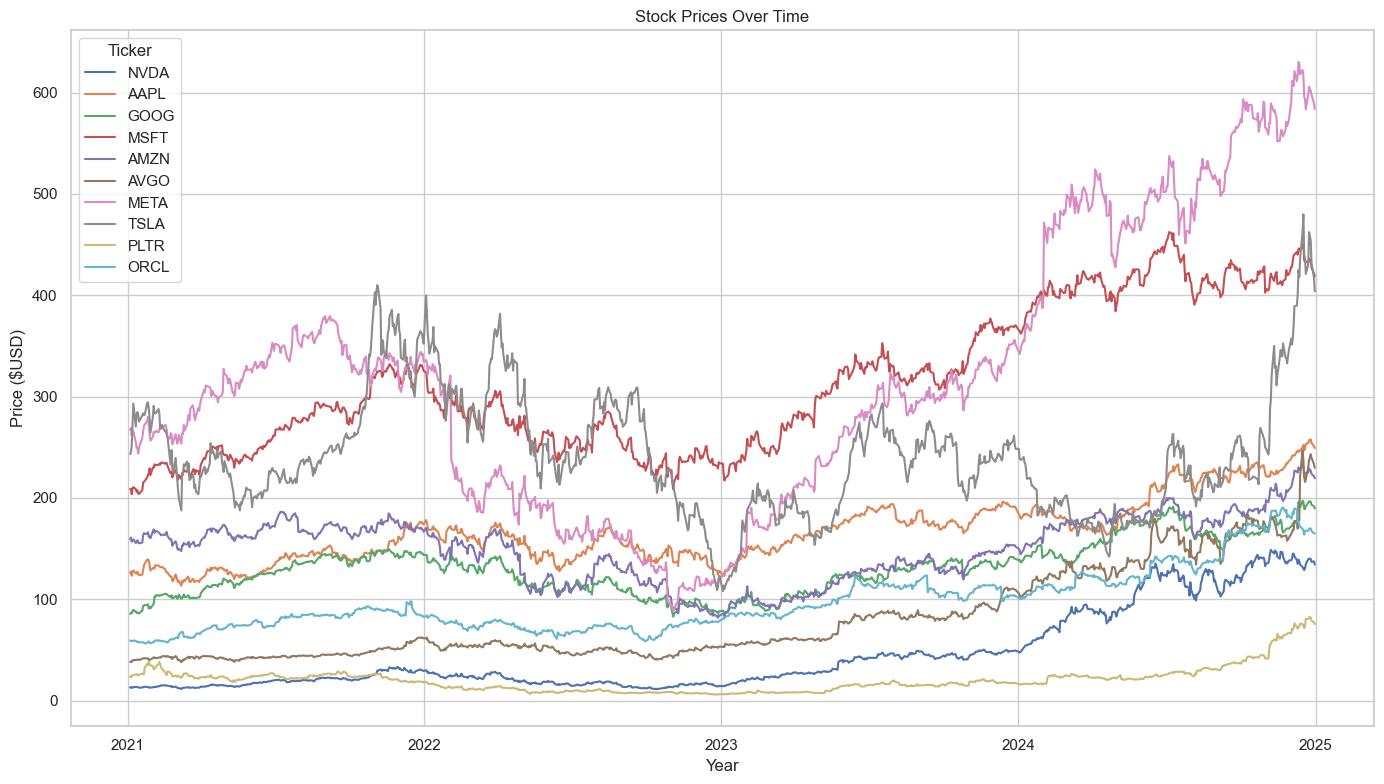

In [99]:
import matplotlib.dates as mdates

plt.figure(figsize=(14,8))
sns.lineplot(data=df_melted, x="Date", y="Price", hue="Ticker")
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.title("Stock Prices Over Time")
plt.xlabel("Year")
plt.ylabel("Price ($USD)")
plt.tight_layout()
plt.show()


#### 2. Which stockes had the highest growth over the period?

In [100]:
df.head()

,Date,NVDA,AAPL,GOOG,MSFT,AMZN,AVGO,META,TSLA,PLTR,ORCL
0,2021-01-04,13.076725,125.974495,85.768723,208.882217,159.331497,38.253101,267.074432,243.256668,23.370001,59.462536
1,2021-01-05,13.367159,127.531967,86.397995,209.083710,160.925507,38.512203,269.090363,245.036667,24.600000,58.725666
2,2021-01-06,12.579125,123.239059,86.118599,203.662323,156.919006,38.274693,261.483490,251.993332,23.540001,58.585220
3,2021-01-07,13.306578,127.444374,88.697258,209.457886,158.108002,39.887699,266.875763,272.013336,25.000000,59.053375
4,2021-01-08,13.239515,128.544388,89.687820,210.734085,159.134995,40.090107,265.713867,293.339996,25.200001,59.343636


In [101]:
print(df.columns)

Index(['Date', 'NVDA', 'AAPL', 'GOOG', 'MSFT', 'AMZN', 'AVGO', 'META', 'TSLA',
       'PLTR', 'ORCL'],
      dtype='object')


In [102]:
df["Date"] = pd.to_datetime(df["Date"])
growth = ((df.iloc[-1, 1:] / df.iloc[0, 1:]) - 1) * 100
print(growth)

NVDA    926.658285
AAPL     97.891257
GOOG    121.177921
MSFT     100.31071
AMZN     37.694055
AVGO    500.640917
META    118.541883
TSLA     66.013947
PLTR    223.620002
ORCL    177.483744
dtype: object


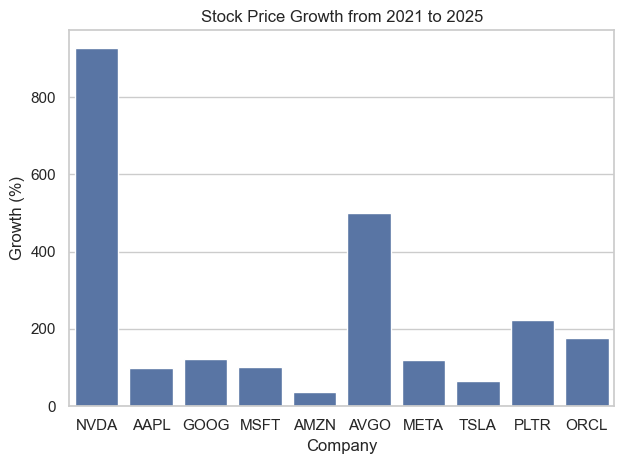

In [103]:
plt.Figure(figsize=(12,6))
sns.barplot(x=growth.index, y=growth.values)
plt.title("Stock Price Growth from 2021 to 2025")
plt.xlabel("Company")
plt.ylabel("Growth (%)")
plt.tight_layout()
plt.show()


#### 3. Distribution of daily return each stock?

In [104]:
plt.figure(figsize=(10, 5))
company= df.columns[1:11]
company

Index(['NVDA', 'AAPL', 'GOOG', 'MSFT', 'AMZN', 'AVGO', 'META', 'TSLA', 'PLTR',
       'ORCL'],
      dtype='object')

<Figure size 1000x500 with 0 Axes>

In [105]:
df_growth = df[company].pct_change() * 100  # daily % change

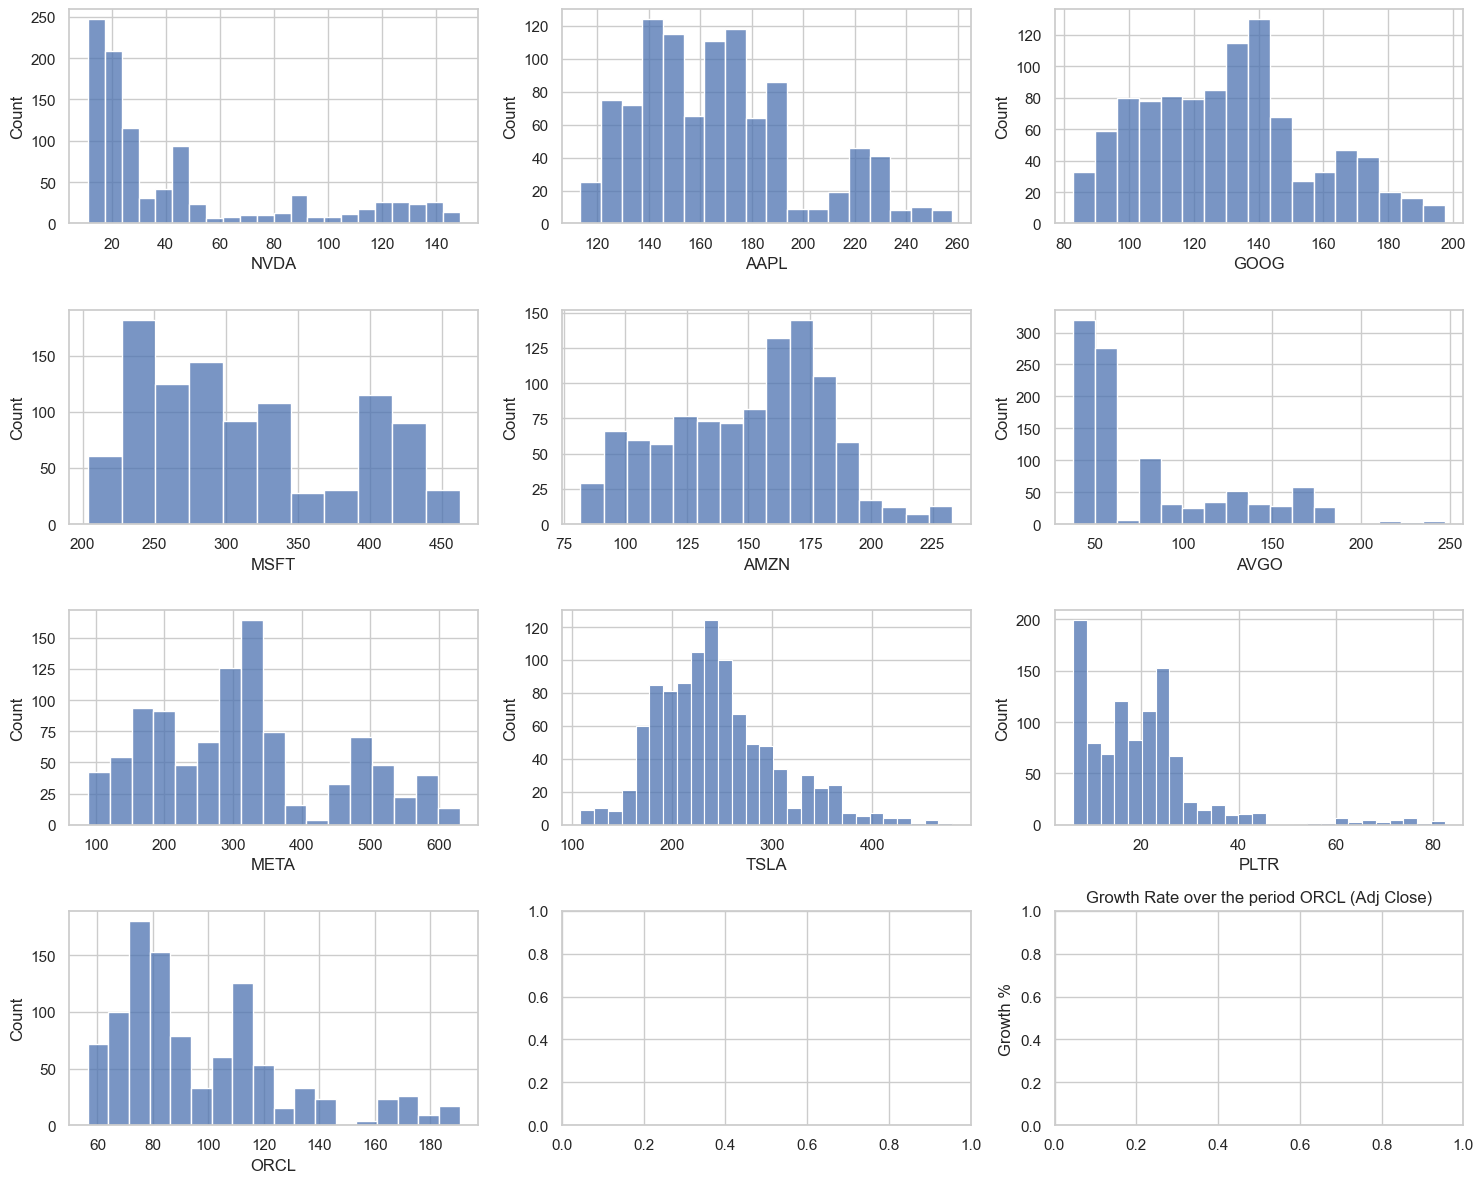

In [106]:
fig, axes = plt.subplots(4, 3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(company):
    sns.histplot(df[col], ax=axes[i])
    plt.title(f"Growth Rate over the period {col} (Adj Close)")
    plt.ylabel("Growth %")

plt.tight_layout()
plt.show()

##### 4. Volatile for stocks(Standard Deviation)

In [107]:
df2 = df.drop('Date', axis=1)

In [108]:
vola = df2.std()
vola.sort_values(ascending=True)

PLTR     12.932589
GOOG     25.805038
ORCL     30.629881
AAPL     31.358061
AMZN     32.324468
NVDA     39.615997
AVGO     45.053671
TSLA     60.200277
MSFT     69.623204
META    132.847122
dtype: float64

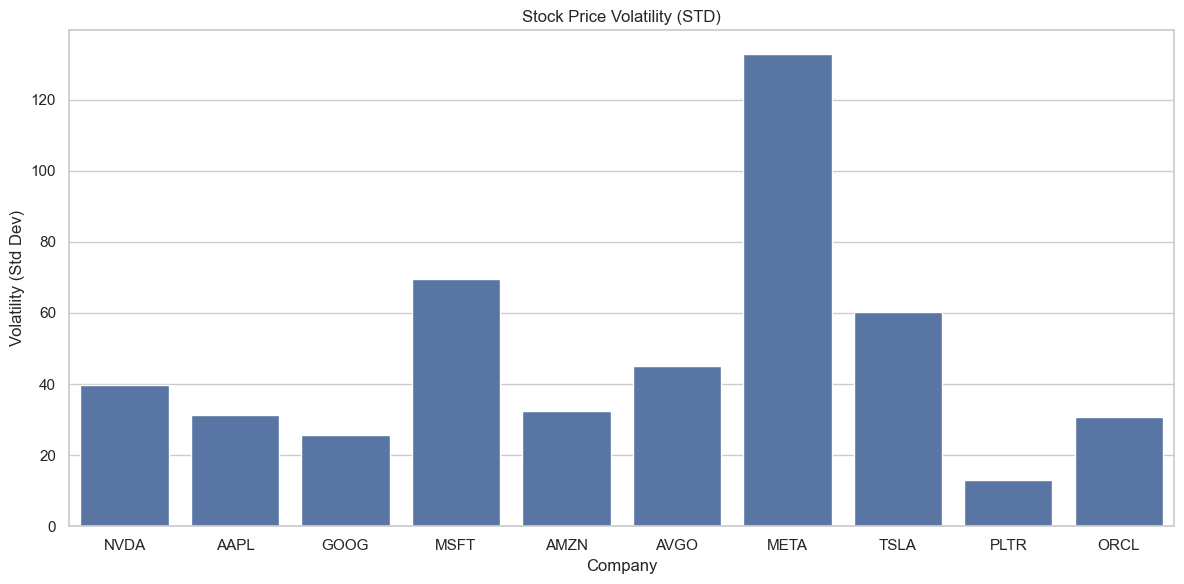

In [109]:
plt.figure(figsize=(12,6))
sns.barplot(x=vola.index, y=vola.values)
plt.title("Stock Price Volatility (STD)")
plt.xlabel("Company")
plt.ylabel("Volatility (Std Dev)")
plt.tight_layout()
plt.show()

#### 5. Correlation betwen stock return

In [110]:
corr = df2.corr()
corr

,NVDA,AAPL,GOOG,MSFT,AMZN,AVGO,META,TSLA,PLTR,ORCL
NVDA,1.000000,0.890379,0.842811,0.918939,0.642058,0.975548,0.876963,0.037600,0.699431,0.939940
AAPL,0.890379,1.000000,0.793861,0.892194,0.498028,0.909283,0.725069,0.238103,0.575787,0.909734
GOOG,0.842811,0.793861,1.000000,0.896293,0.819366,0.809972,0.884239,0.284306,0.668076,0.792038
MSFT,0.918939,0.892194,0.896293,1.000000,0.642052,0.921871,0.866385,0.070527,0.563327,0.889557
AMZN,0.642058,0.498028,0.819366,0.642052,1.000000,0.585646,0.862014,0.394370,0.806300,0.556908
AVGO,0.975548,0.909283,0.809972,0.921871,0.585646,1.000000,0.841698,0.037001,0.672394,0.930866
META,0.876963,0.725069,0.884239,0.866385,0.862014,0.841698,1.000000,0.115430,0.804817,0.830911
TSLA,0.037600,0.238103,0.284306,0.070527,0.394370,0.037001,0.115430,1.000000,0.400352,0.082105
PLTR,0.699431,0.575787,0.668076,0.563327,0.806300,0.672394,0.804817,0.400352,1.000000,0.696849
ORCL,0.939940,0.909734,0.792038,0.889557,0.556908,0.930866,0.830911,0.082105,0.696849,1.000000


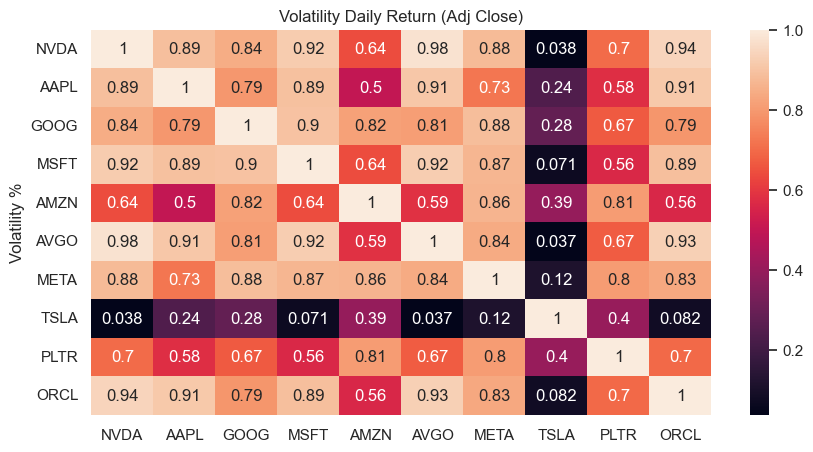

In [111]:
plt.figure(figsize=(10, 5))
sns.heatmap(corr, annot=True)
plt.title("Volatility Daily Return (Adj Close)")
plt.ylabel("Volatility %")
plt.show()

In [112]:
daily_return = df2.pct_change().dropna()
daily_return

,NVDA,AAPL,GOOG,MSFT,AMZN,AVGO,META,TSLA,PLTR,ORCL
1,0.022210,0.012363,0.007337,0.000965,0.010004,0.006773,0.007548,0.007317,0.052632,-0.012392
2,-0.058953,-0.033661,-0.003234,-0.025929,-0.024897,-0.006167,-0.028269,0.028390,-0.043089,-0.002392
3,0.057830,0.034123,0.029943,0.028457,0.007577,0.042143,0.020622,0.079447,0.062022,0.007991
4,-0.005040,0.008631,0.011168,0.006093,0.006496,0.005074,-0.004354,0.078403,0.008000,0.004915
5,0.025967,-0.023249,-0.022405,-0.009698,-0.021519,0.000269,-0.040102,-0.078214,0.028968,-0.005522
...,...,...,...,...,...,...,...,...,...,...
1000,0.003938,0.011478,0.008062,0.009374,0.017729,0.031547,0.013170,0.073572,0.020944,0.013421
1001,-0.002068,0.003176,-0.002379,-0.002777,-0.008732,0.023698,-0.007240,-0.017630,-0.002913,0.001575
1002,-0.020867,-0.013242,-0.015525,-0.017301,-0.014534,-0.014713,-0.005867,-0.049479,-0.037253,-0.015843
1003,0.003503,-0.013263,-0.006957,-0.013240,-0.010950,-0.025522,-0.014288,-0.033012,-0.024026,-0.012133


#### 6. Largest stock move

In [113]:
larges = daily_return.abs().max().sort_values(ascending=False)
larges

PLTR    0.308014
META    0.263901
AVGO    0.244326
NVDA    0.243696
TSLA    0.219190
ORCL    0.156134
AMZN    0.140494
GOOG    0.099652
AAPL    0.088975
MSFT    0.082268
dtype: float64

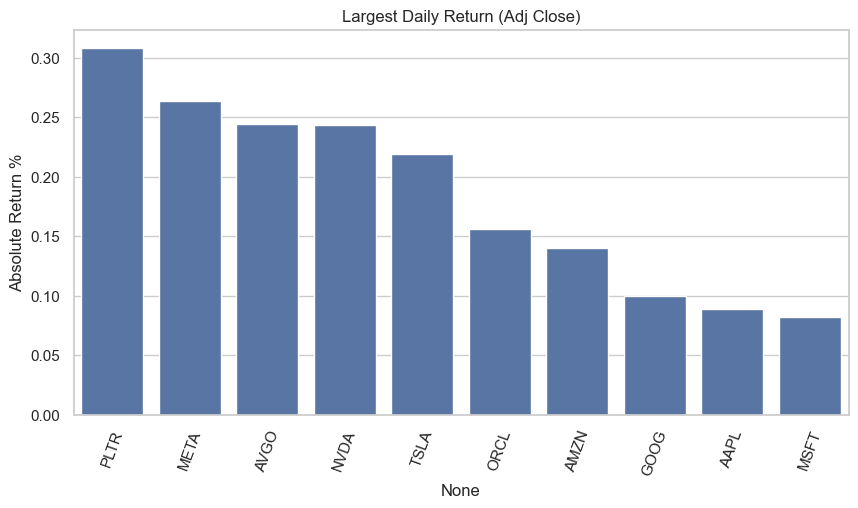

In [114]:
plt.figure(figsize=(10, 5))
sns.barplot(x=larges.index, y=larges.values)
plt.title("Largest Daily Return (Adj Close)")
plt.ylabel("Absolute Return %")
plt.xticks(rotation=70)
plt.show()